In [9]:
%load_ext autoreload
%autoreload 2

import torch
from ncpu.runner  import setup_trainer
from ncpu.config import TINY_AND_GATE_TRAINING_CONFIG, BIG_4BIT_ADDER_TRAINING_CONFIG

from matplotlib import pyplot as plt
from IPython.display import clear_output, display
from tqdm.auto import tqdm

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
config = BIG_4BIT_ADDER_TRAINING_CONFIG
trainer = setup_trainer(config)

Sanity check...
  forward: torch.Size([2, 16, 117, 117]) -> torch.Size([2, 11, 16, 117, 117])
  batch: 2
  dataloader: torch.Size([16, 117, 117]) -> torch.Size([16, 117, 117])
  first_state: torch.Size([16, 16, 117, 117])
  rollout: torch.Size([16, 11, 16, 117, 117])
  loss: 0.008169143460690975
Sanity check completed successfully


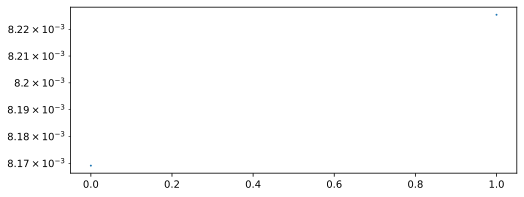

inp    : (16, 117, 117) torch.float32, min=0.00, max=1.03, mean=0.02, std=0.14
out    : (16, 117, 117) torch.float32, min=0.00, max=1.00, mean=0.01, std=0.11
nca_out: (16, 117, 117) torch.float32, min=0.00, max=1.03, mean=0.02, std=0.14


,,,,,,,
,,,,,,,
,,,,,,,

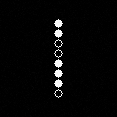
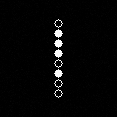
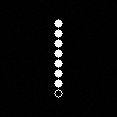
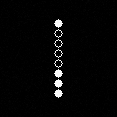
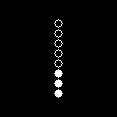
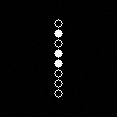
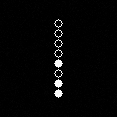
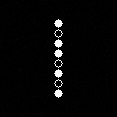
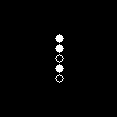
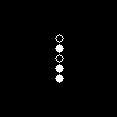
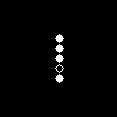
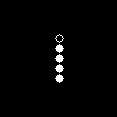
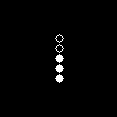
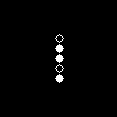
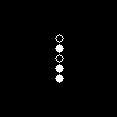
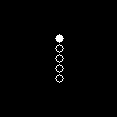
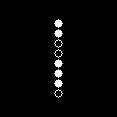
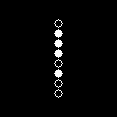
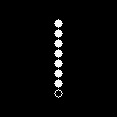
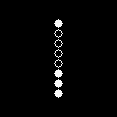
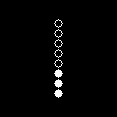
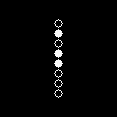
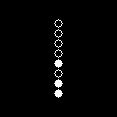
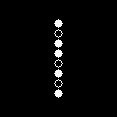

#0,#1,#2,#3,#4,#5,#6,#7

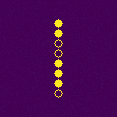
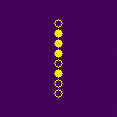
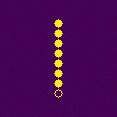
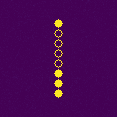
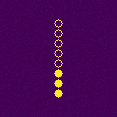
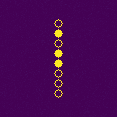
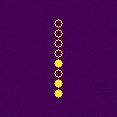
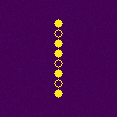

In [ ]:
# with torch.no_grad():
#     info = trainer.optim_step(steps=(30, 80))
#     trainer.display_optim_step(info)

loss=0.007929:   0%|          | 0/100000 [00:00<?, ?it/s]

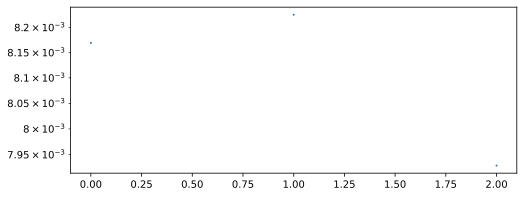

inp    : (16, 117, 117) torch.float32, min=0.00, max=1.03, mean=0.02, std=0.14
out    : (16, 117, 117) torch.float32, min=0.00, max=1.00, mean=0.01, std=0.11
nca_out: (16, 117, 117) torch.float32, min=0.00, max=1.03, mean=0.02, std=0.14


,,,,,,,
,,,,,,,
,,,,,,,

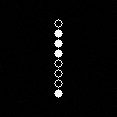
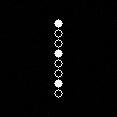
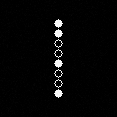
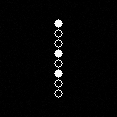
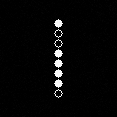
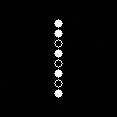
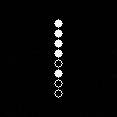
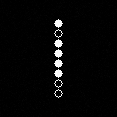
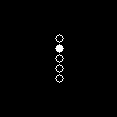
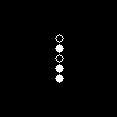
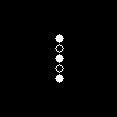
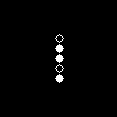
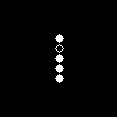
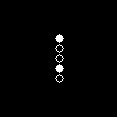
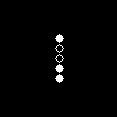
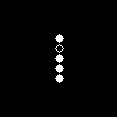
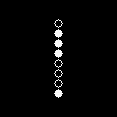
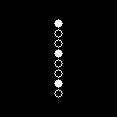
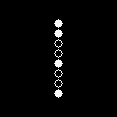
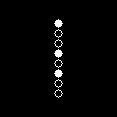
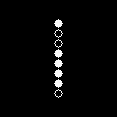
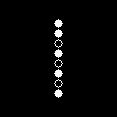
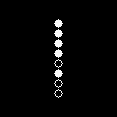
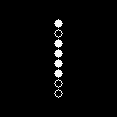

#0,#1,#2,#3,#4,#5,#6,#7

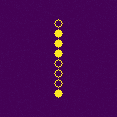
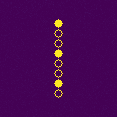
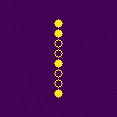
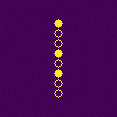
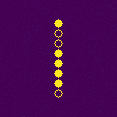
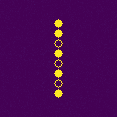
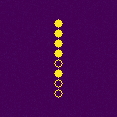
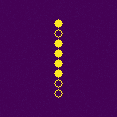

KeyboardInterrupt: 

In [ ]:
pbar = tqdm(range(100_000))

for i in pbar:
    info = trainer.optim_step(steps=(30, 80))
    loss = info["metrics"]["loss"].item()
    pbar.set_description(f"loss={loss:.6f}")

    if i % 100 == 0:
        clear_output(wait=False)
        display(pbar.container)

        trainer.display_optim_step(info)
        trainer.save_checkpoint()

In [ ]:
1